# BASE CLUSTER MODELLING

For the clusterning based on the issues type, 
* Centroid based clustering - KMeans
* Hierarchical based clustering - HAC



In [1]:
# Import the necessary modules
import numpy as np
import scipy.sparse as sp
import sys
import os 
import pandas as pd 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# This 'goes up' two levels from your current subfolder to reach the project root
root_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))

if root_path not in sys.path:
    sys.path.insert(0, root_path)

In [3]:
from src.evaluation.ClusterEvaluation import evaluate_clusters
from src.clustering.KMeans import run_kmeans
from src.clustering.Hac import run_hac
from src.features.Embeddings import bow_vectorizer, vectorize_boa, tfidf_vectorizer, vectorize_tfidf
from src.evaluation.Cluster_Interpretability import plot_cluster_top_words, plot_cluster_heatmaps, plot_cluster_size
from src.evaluation.Cluster_Stability import visualize_cluster_stability

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Define the data directory relative to the root
data_dir = os.path.join(root_path, 'data', 'processed')
source_data_dir = os.path.join(root_path, 'data', 'raw')
file_name = 'customer_support_tickets.csv' 
file_path = os.path.join(source_data_dir, file_name)

# load the dataframe
df = pd.read_csv(file_path)
print(df.head())

# 1. Bag of Words
bow_path = os.path.join(data_dir, 'bow_vectors.npz')
X_bow = sp.load_npz(bow_path)

# 2. TF-IDF
tfidf_path = os.path.join(data_dir, 'tfidf_vectors.npz')
X_tfidf = sp.load_npz(tfidf_path)

# 3. Skipgram
skipgram_path = os.path.join(data_dir, 'skipgram_embeddings.npy')
X_skipgram = np.load(skipgram_path)

# 4. SBERT
sbert_path = os.path.join(data_dir, 'sbert_embeddings.npy')
X_sbert = np.load(sbert_path)

print(f"Successfully loaded BoW from: {bow_path}")
print(f"Successfully loaded TF-IDF from: {tfidf_path}")
print(f"Successfully loaded Skipgram from: {skipgram_path}")
print(f"Successfully loaded SBERT from: {sbert_path}")

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [5]:
# Clustering sweep 
def run_clustering_sweep(X, y_type, y_subj, name, metric='cosine', k_range=range(2, 11)):
    results = []
    for k in k_range:
        # KMeans 
        km_labels = run_kmeans(X = X, k = k)
        # Kmeans scores on ticket type 
        km_sil, km_ari_type, km_nmi_type = evaluate_clusters(
            X = X, 
            cluster_labels = km_labels, 
            true_labels = y_type, 
            metric=metric
        )
        # Kmeans scores on ticket type 
        km_sil, km_ari_subj, km_nmi_subj = evaluate_clusters(
            X = X, 
            cluster_labels = km_labels, 
            true_labels = y_subj, 
            metric=metric
        )
        # Append the current k label and scores  
        results.append({'Representation': name, 'Algorithm': 'KMeans', 'k': k,
            'Silhouette': km_sil, 'ARI (Type)': km_ari_type, 'NMI (Type)': km_nmi_type,
            'ARI (Subject)': km_ari_subj, 'NMI (Subject)': km_nmi_subj})
        # HAC
        hac_labels = run_hac(X = X, k = k)
        # HAC scores on ticket type
        hac_sil, hac_ari_type, hac_nmi_type = evaluate_clusters(
            X = X, 
            cluster_labels = hac_labels, 
            true_labels = y_type,
            metric=metric
        )
        # HAC scores on ticket type 
        hac_sil, hac_ari_subj, hac_nmi_subj = evaluate_clusters(
            X = X, 
            cluster_labels = hac_labels, 
            true_labels = y_subj,
            metric=metric
        )
        # Append the current k label and scores
        results.append({'Representation': name, 'Algorithm': 'HAC', 'k': k,
            'Silhouette': hac_sil, 'ARI (Type)': hac_ari_type, 'NMI (Type)': hac_nmi_type,
            'ARI (Subject)': hac_ari_subj, 'NMI (Subject)': hac_nmi_subj})
    return pd.DataFrame(results)

In [6]:
# Encode the ticket type and ticket subject
le = LabelEncoder()
y_type = le.fit_transform(df['Ticket Type'])
y_subj = le.fit_transform(df['Ticket Subject'])

In [7]:
# clustering 
df_tfidf = run_clustering_sweep(X_tfidf, y_type, y_subj, 'TF-IDF', metric='cosine')
df_sbert = run_clustering_sweep(X_sbert, y_type, y_subj, 'SBERT', metric='cosine')
df_bow = run_clustering_sweep(X_bow, y_type, y_subj, 'BoW', metric='cosine')
df_skip = run_clustering_sweep(X_skipgram, y_type, y_subj, 'Skipgram', metric='cosine')

# Final results
all_results = pd.concat([df_tfidf, df_sbert, df_bow, df_skip], ignore_index=True)

In [8]:
all_results.head()

,Representation,Algorithm,k,Silhouette,ARI (Type),NMI (Type),ARI (Subject),NMI (Subject)
0,TF-IDF,KMeans,2,0.034502,-0.000068,0.000457,-0.000059,0.000525
1,TF-IDF,HAC,2,0.023795,-0.000044,0.000418,-0.000005,0.000455
2,TF-IDF,KMeans,3,0.045429,-0.000201,0.000593,0.000021,0.000919
3,TF-IDF,HAC,3,0.029134,-0.000138,0.000636,-0.000026,0.000893
4,TF-IDF,KMeans,4,0.067254,-0.000061,0.000661,-0.000013,0.001214


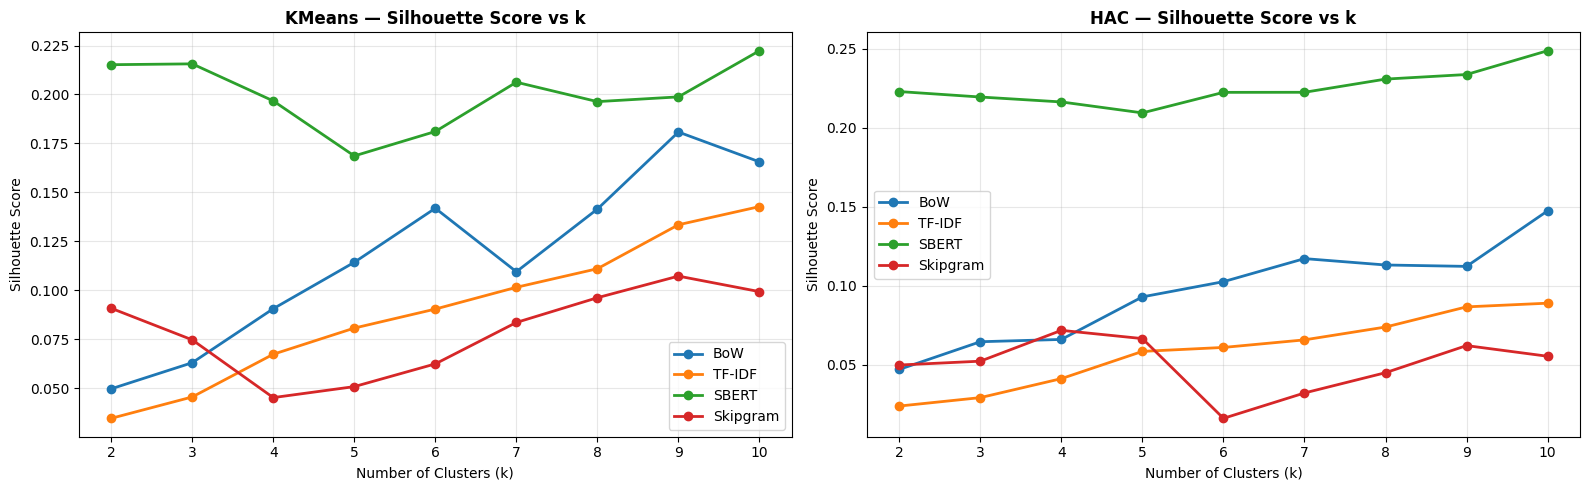

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, algo in zip(axes, ['KMeans', 'HAC']):
    subset = all_results[all_results['Algorithm'] == algo]
    for rep in ['BoW', 'TF-IDF', 'SBERT', 'Skipgram']:
        rep_data = subset[subset['Representation'] == rep]
        ax.plot(rep_data['k'], rep_data['Silhouette'], marker='o', label=rep, linewidth=2)
    ax.set_title(f'{algo} — Silhouette Score vs k', fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)')
    ax.set_ylabel('Silhouette Score')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))
plt.tight_layout()
plt.show()

# CONCLUSIONS OF CLUSTERING ANALYSIS ON TICKET CORPUS

### TEXT REPRESENTATION COMPARISON — SILHOUETTE ANALYSIS

* SBERT Embeddings (best performer):
  - KMeans silhouette scores range from 0.15 to 0.23, peaking at k=3 (0.23)
  and k=9 (0.22). This is the highest across all representations.
  - HAC scores follow a similar pattern, peaking around k=8–9 (~0.22).
  - The early peak at k=3 suggests approximately 2–3 natural semantic groupings exist in the embedding space, while the secondary peak at
  higher k indicates the presence of finer-grained sub-clusters.
  - SBERT produces identical results with and without custom stopwords,
  confirming that the light preprocessing path (no stopword removal or lemmatisation) is corre SBERT captures semantics from natural
  sentence structure rather than individual token frequencies.

* Bag-of-Words (mid-range):
  - KMeans silhouette scores range from 0.10 to 0.17 (without custom stopwords) and 0.05 to 0.20 (with custom stopwords).
  - Silhouette generally increases with k suggesting the algorithm is finding smaller, tighter micro-clusters in the sparse high-dimensional space rather than broad thematic groupings.
  - Custom stopword removal (adding 'issue', 'problem', 'assist', 'product'
  etc.) improves scores at higher k values, indicating these template
  words were diluting cluster separability.
  - With max_df=0.85 filtering, the BoW vectorizer excludes terms appearing in more than 85% of documents, removing the most ubiquitous template
  vocabulary from the feature space.

* TF-IDF (weakest performer):
  - KMeans silhouette scores range from 0.03 to 0.13, the lowest across all representations.
  - This is initially surprising since TF-IDF is designed to upweight discriminative terms. However, in this corpus the discriminative terms
  that survive TF-IDF weighting carry very little semantic signal after downweighting the dominant template vocabulary, what remains are
  low-frequency incidental words (zip codes, handles, fragments) rather
  than issue-specific language.
  - Custom stopword removal marginally improves TF-IDF scores but does not close the gap with BoW or SBERT.

### KEY FINDING:
* Semantic embeddings (SBERT) capture substantially more cluster-relevant structure than frequency-based representations (BoW,
TF-IDF) in this corpus.
* This suggests that the discriminative signal between ticket categories lies in sentence-level meaning rather than individual word frequencies consistent with a templated corpus where
word distributions are nearly identical across categories.

### 3. ALGORITHM COMPARISON

* KMeans vs HAC:
  - KMeans consistently outperforms HAC in silhouette scores across all representations.  
  - For SBERT at k=3, KMeans achieves 0.23 compared to HAC's 0.15.
  - However, at higher k values (k=8–9), HAC closes the gap and sometimes matches or exceeds KMeans (e.g., HAC achieves 0.22 at k=9 on SBERT).
  - This pattern suggests that KMeans is better at  finding broad, balanced partitions while HAC can discover more nuanced hierarchical structure
  at finer granularity.

### KEY FINDING:
* Centroid-based methods (KMeans) are the most robust choice for this data.
* DBSCAN is unsuitable for sparse text vectors but partially viable on dense embeddings.
* HAC provides complementary insights at higher
k values.


### 4. CLUSTER ALIGNMENT WITH KNOWN LABELS (ARI / NMI)

* This is the most significant finding of the preliminary analysis.

* Across ALL configurations tested — every combination of representation
(BoW, TF-IDF, SBERT), algorithm (KMeans, HAC, DBSCAN), k value (2–14),
and stopword setting  the Adjusted Rand Index (ARI) and Normalised
Mutual Information (NMI) against both Ticket Type (5 categories) and
Ticket Subject (10 categories) are effectively zero:

  - ARI ranges from -0.001 to +0.001
  - NMI ranges from 0.0001 to 0.006

* These values indicate NO systematic correspondence between the clusters
discovered from text content and the existing metadata label categories.
* This result is consistent across both evaluation targets and is not an
artefact of any single method or representation.

### INTERPRETATION:
* The Ticket Type and Ticket Subject labels assigned to each ticket are not distinguishable from the textual content of the ticket
descriptions. This is directly explained by the EDA findings:

  1. Template homogeneity: 100% of tickets use the same structural template ("I am having an issue with {product_purchased}. Please assist."), making language patterns nearly identical across categories.

  2. Uniform vocabulary distribution: N-gram analysis shows the same top unigrams, bigrams, and trigrams appear across all Ticket Types
  with similar frequencies.

  3. Balanced metadata: Cross-tabulation heatmaps confirm that Ticket Priority, Channel, and Product are evenly distributed across all
  Ticket Types no category has distinctive contextual markers.

* This does NOT mean the clustering is failing. The silhouette scores
(especially SBERT at 0.22) indicate that clusters with internal coherence
do exist — they simply capture a different structure in the data than
the pre-assigned labels. Identifying what these clusters represent
(through topic modelling and cluster interpretation in Part 2) is the
logical next step.


### 5. STABILITY ANALYSIS : silhouette-vs-k plots analysis:

* BoW / TF-IDF:
  - Silhouette scores increase approximately monotonically with k.
  - No clear "elbow" or peak, suggesting there is no natural cluster count
  in these representations — the algorithm simply finds tighter groupings
  as k increases.
  - This monotonic increase is characteristic of data without well-separated
  clusters, where increasing k always reduces intra-cluster variance.

* SBERT:
  - Shows a more informative pattern: peak at k=3 (0.23), dip at k=4–5
  (~0.15), then gradual recovery toward k=9 (0.22).
  - The k=3 peak suggests a coarse 3-way partition is the most natural
  grouping in semantic space.
  - The dip-then-recovery pattern indicates that k=4–5 splits a natural
  cluster, degrading coherence, but by k=8–9 the algorithm has found
  enough fine-grained structure to compensate.
  - This non-monotonic pattern is evidence of genuine structure — unlike
  BoW/TF-IDF where higher k always helps mechanically.

* Custom stopword impact:
  - For BoW, custom stopwords improve scores at higher k (from 0.17 to
  0.20 at k=9), confirming that removing template filler exposes more
  discriminative features.
  - For TF-IDF, the improvement is marginal (~0.01), consistent with
  TF-IDF already downweighting high-frequency terms.
  - For SBERT, no change (as expected — stopwords are not removed in the
  SBERT preprocessing path).

### 6. PCA VISUALISATION FINDINGS

  - BoW PCA: Likely shows a diffuse, roughly circular cloud with no
  visible cluster separation. Points coloured by Ticket Type or Subject
  should be fully intermixed. Note the explained variance — if PC1 and
  PC2 capture only ~2-5% of total variance, that means the meaningful
  variation is spread across hundreds of dimensions.

  - TF-IDF PCA: Similar diffuse pattern, possibly even more spread out
  due to the sparsity of TF-IDF vectors after downweighting.

  - SBERT PCA: May show slightly more structure — elongated or multi-modal
  distribution rather than a uniform cloud. Even if clusters aren't
  visually distinct, any directional tendency supports the higher
  silhouette scores. If PC1+PC2 capture more variance than BoW/TF-IDF,
  that indicates SBERT concentrates information in fewer dimensions.

For all representations, colouring by Ticket Type and Ticket Subject
should show complete intermixing — no colour forms a distinct region.
This visually confirms the near-zero ARI/NMI findings.

### 7. CLUSTER VISUALISATION FINDINGS

* For KMeans on SBERT (your best configuration):
  - Left panel (cluster assignments) should show coloured regions that
  partially separate in PCA space — this is the structure the algorithm
  found.
  - Middle panel (Ticket Type) and Right panel (Ticket Subject) should
  show uniform mixing — confirming that the cluster structure does not
  correspond to these labels.
  - The contrast between "clusters exist" (left) and "but they don't match
  labels" (middle/right) is the visual proof of your ARI/NMI finding.

* For KMeans on BoW/TF-IDF:
  - All three panels likely show diffuse mixing with less visible cluster
  separation than SBERT.

* For DBSCAN on SBERT:
  - Should show most points as noise (grey/uncoloured) with a few small
  dense groups, confirming the high noise counts in your scores.

### 8. PREPROCESSING IMPACT

* Contraction expansion:
  - Eliminated ghost tokens ('im', 'ive', 'cant') that were polluting
  the vocabulary after apostrophe removal. Before: "I'm" → "im" (junk).
  After: "I'm" → "I am" → properly handled by stopword removal.

* SBERT light path:
  - By skipping stopword removal and lemmatisation for SBERT, we preserve
  the natural sentence structure that the pre-trained model expects.
  SBERT's superior performance (0.22 vs 0.17 for BoW, 0.13 for TF-IDF)
  validates this design choice.

* Custom stopwords:
  - Adding domain-specific template words ('issue', 'problem', 'assist',
  'product', 'experiencing', 'facing') to the stopword list removes
  terms that appear uniformly across all categories. This improves BoW
  clustering by ~0.03 at higher k values, confirming that these words
  were adding noise without discriminative value.

* max_df filtering:
  - Setting max_df=0.85 on both BoW and TF-IDF vectorizers filters terms
  appearing in more than 85% of documents. This catches any remaining
  template vocabulary that slipped past stopword removal.

### 9. CONCLUSIONS

The preliminary clustering analysis reveals three key findings:

1. SEMANTIC REPRESENTATIONS OUTPERFORM FREQUENCY-BASED METHODS:
   SBERT embeddings consistently achieve higher silhouette scores
   (0.15–0.23) than BoW (0.10–0.20) and TF-IDF (0.03–0.13), indicating
   that sentence-level semantic similarity captures more structure in
   customer support text than word-level frequency patterns.

2. TEXT CONTENT DOES NOT SEPARATE BY EXISTING LABELS:
   Near-zero ARI and NMI across all configurations demonstrate that
   Ticket Type and Ticket Subject categories cannot be recovered from
   ticket description text alone. This is a direct consequence of
   template-driven language homogeneity identified in the EDA.

3. CLUSTERS EXIST BUT CAPTURE DIFFERENT STRUCTURE:
   Silhouette scores above 0.20 (SBERT, KMeans) confirm that meaningful
   groupings exist in the data — they simply correspond to something
   other than the pre-assigned metadata labels. Identifying what these
   clusters represent requires methods capable of extracting soft thematic
   signals from homogeneous text.


## CLUSTER INTERPERTABILITY

#### Cluster Interpertability for the KMean on Ticket Issues 
 - The number of clusters, k = 5, was selected based on the number of ticket issues, which makes it a natural hypothesis to assume the number of clusters and a direct mapping of ticket issues with the clusters. 
- While silhouette scores do not show a sharp elbow at k=5, the balanced class distribution across ticket types further supports this selection, as KMeans performs optimally with similarly sized clusters.

In [10]:
# KM for BoW
km_bow_labels = run_kmeans(X = X_bow.toarray(), k = 5)

# KM for TFIDF
km_tfidf_labels = run_kmeans(X = X_tfidf.toarray(), k = 5)

# KM for Skipgram
km_skipgram_labels = run_kmeans(X = X_skipgram, k = 5)

# KM for sbert 
km_sbert_labels = run_kmeans(X = X_sbert, k = 5)

#### BoW and TF-IDF top 10 selected words

In [11]:
# cleaned text 
cleaned_text_df = pd.read_csv(os.path.join(root_path, "data/processed/cleaned_text.csv"))

len(cleaned_text_df["cleaned_description"])

8469

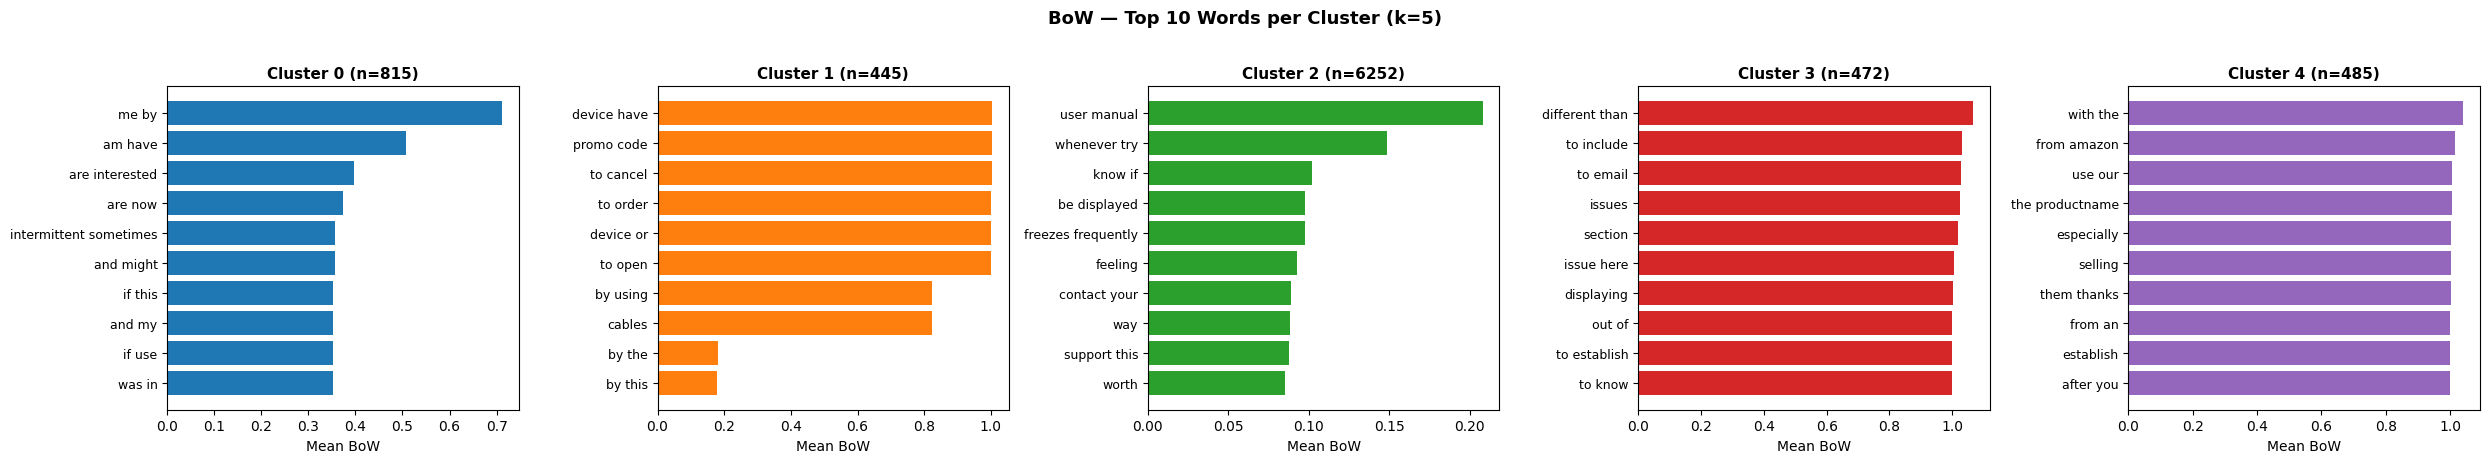

In [12]:
# BoW 
vectorize_boa(text_list = cleaned_text_df["cleaned_description"].to_list())
plot_cluster_top_words(X = X_bow.toarray(), 
                       cluster_labels = km_bow_labels, 
                       vectorizer = bow_vectorizer, 
                       n_top=10, 
                       title_prefix="BoW")

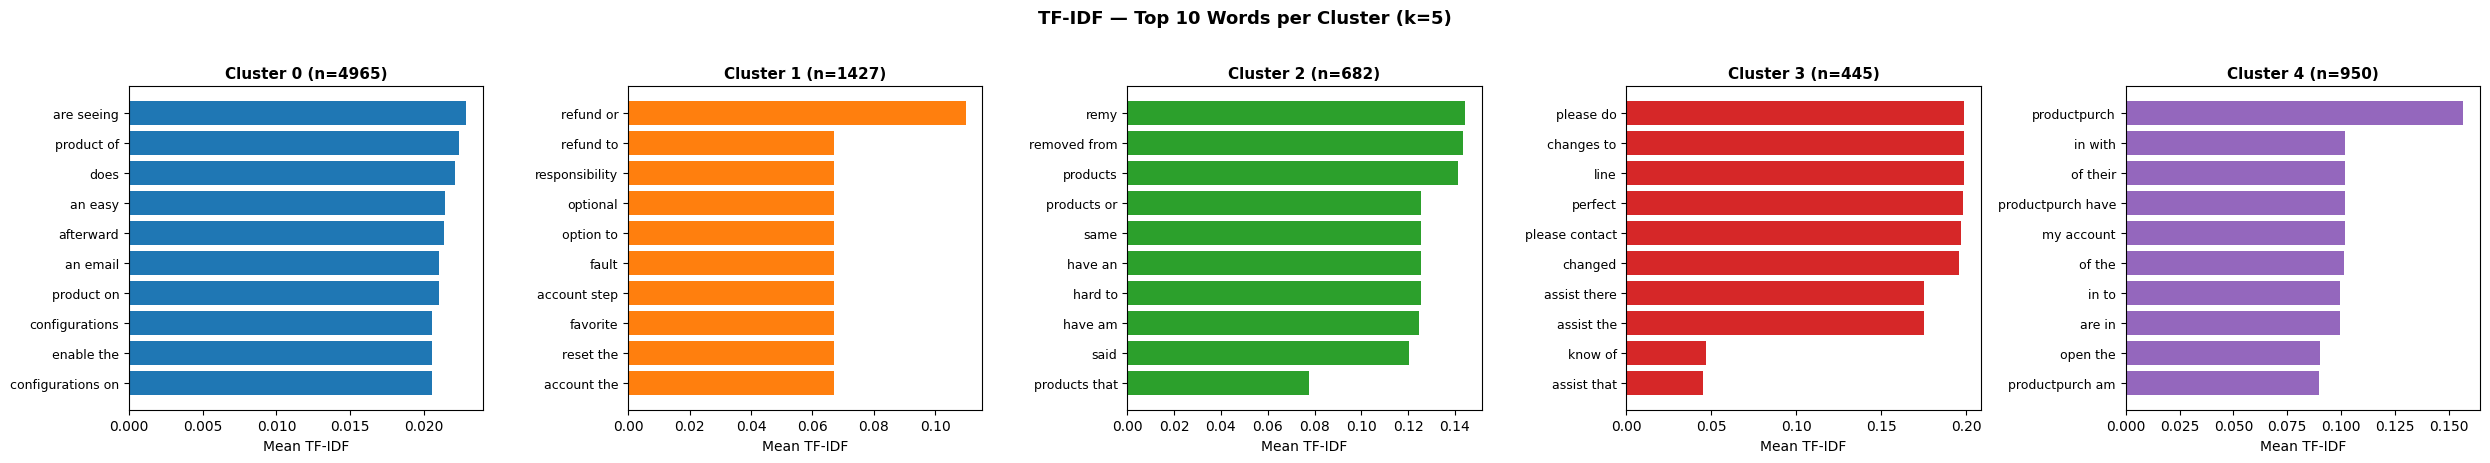

In [13]:
# TF-IDF
vectorize_tfidf(text_list = cleaned_text_df["cleaned_description"].to_list())
plot_cluster_top_words(X = X_tfidf.toarray(), 
                       cluster_labels = km_tfidf_labels, 
                       vectorizer = tfidf_vectorizer, 
                       n_top=10, 
                       title_prefix="TF-IDF")

#### BoW, TF-IDF, Skipgram and SBERT heatmap for the clusters count and proportions 

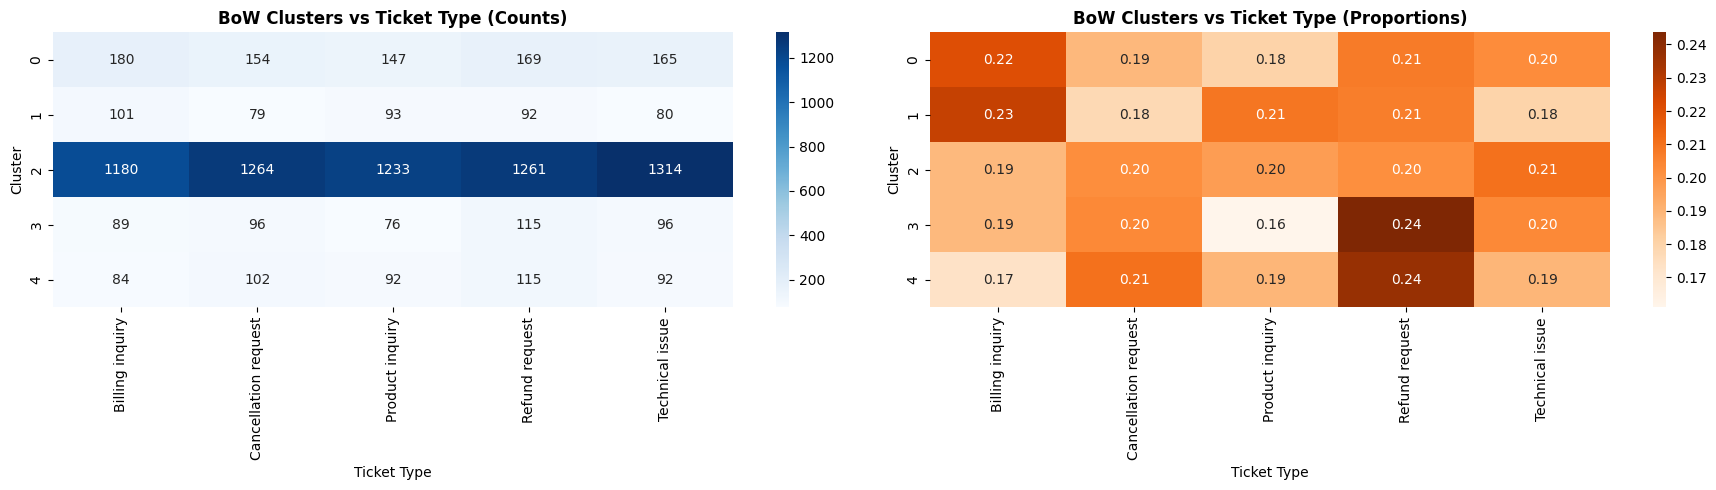

In [14]:
# BoW 
plot_cluster_heatmaps(
    cluster_labels = km_bow_labels, 
    df = df, 
    title_prefix="BoW"
)

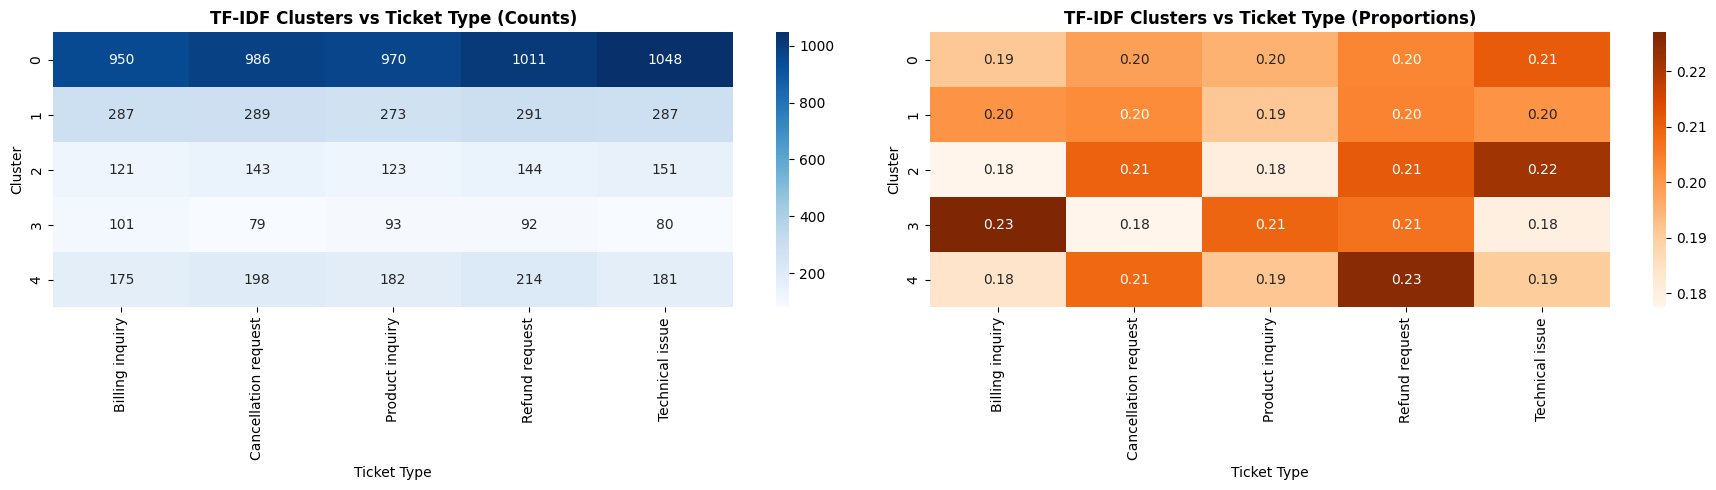

In [15]:
# TF-IDF 
plot_cluster_heatmaps(
    cluster_labels = km_tfidf_labels, 
    df = df, 
    title_prefix="TF-IDF"
)

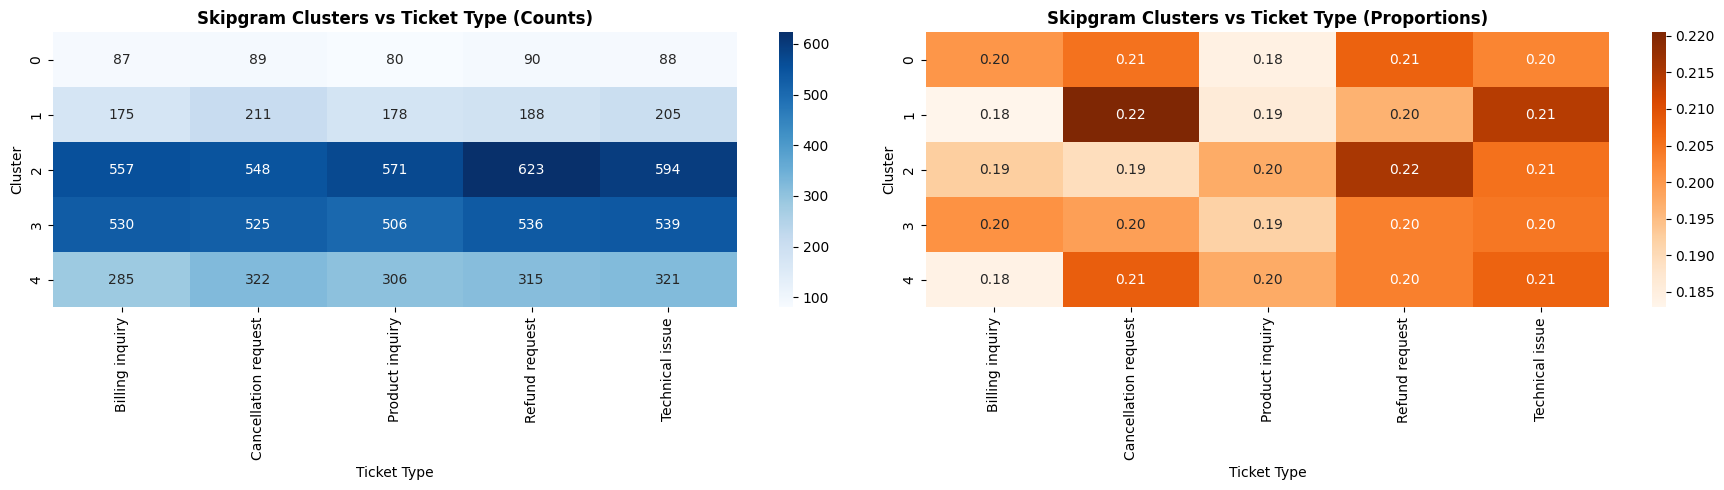

In [16]:
# Skipgram
plot_cluster_heatmaps(
    cluster_labels = km_skipgram_labels, 
    df = df, 
    title_prefix="Skipgram"
)

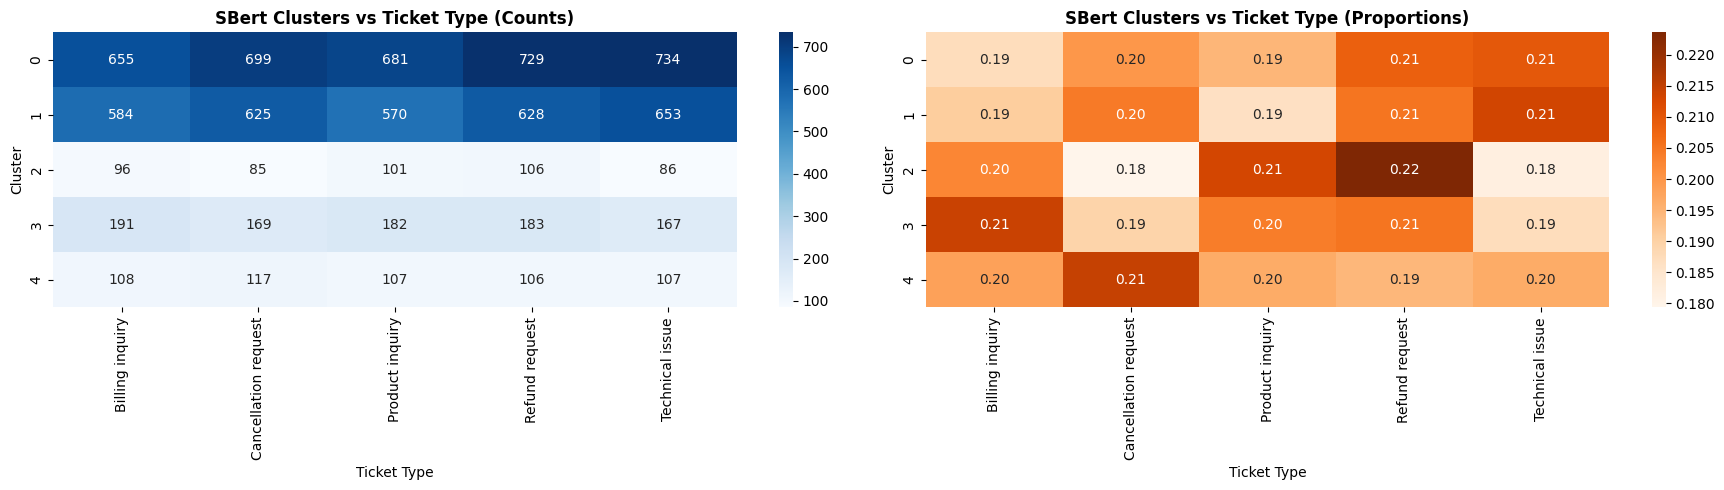

In [17]:
# Sbert
plot_cluster_heatmaps(
    cluster_labels = km_sbert_labels, 
    df = df, 
    title_prefix="SBert"
)

#### BoW, TF-IDF, Skipgram and SBERT - Compare the cluster sizes  

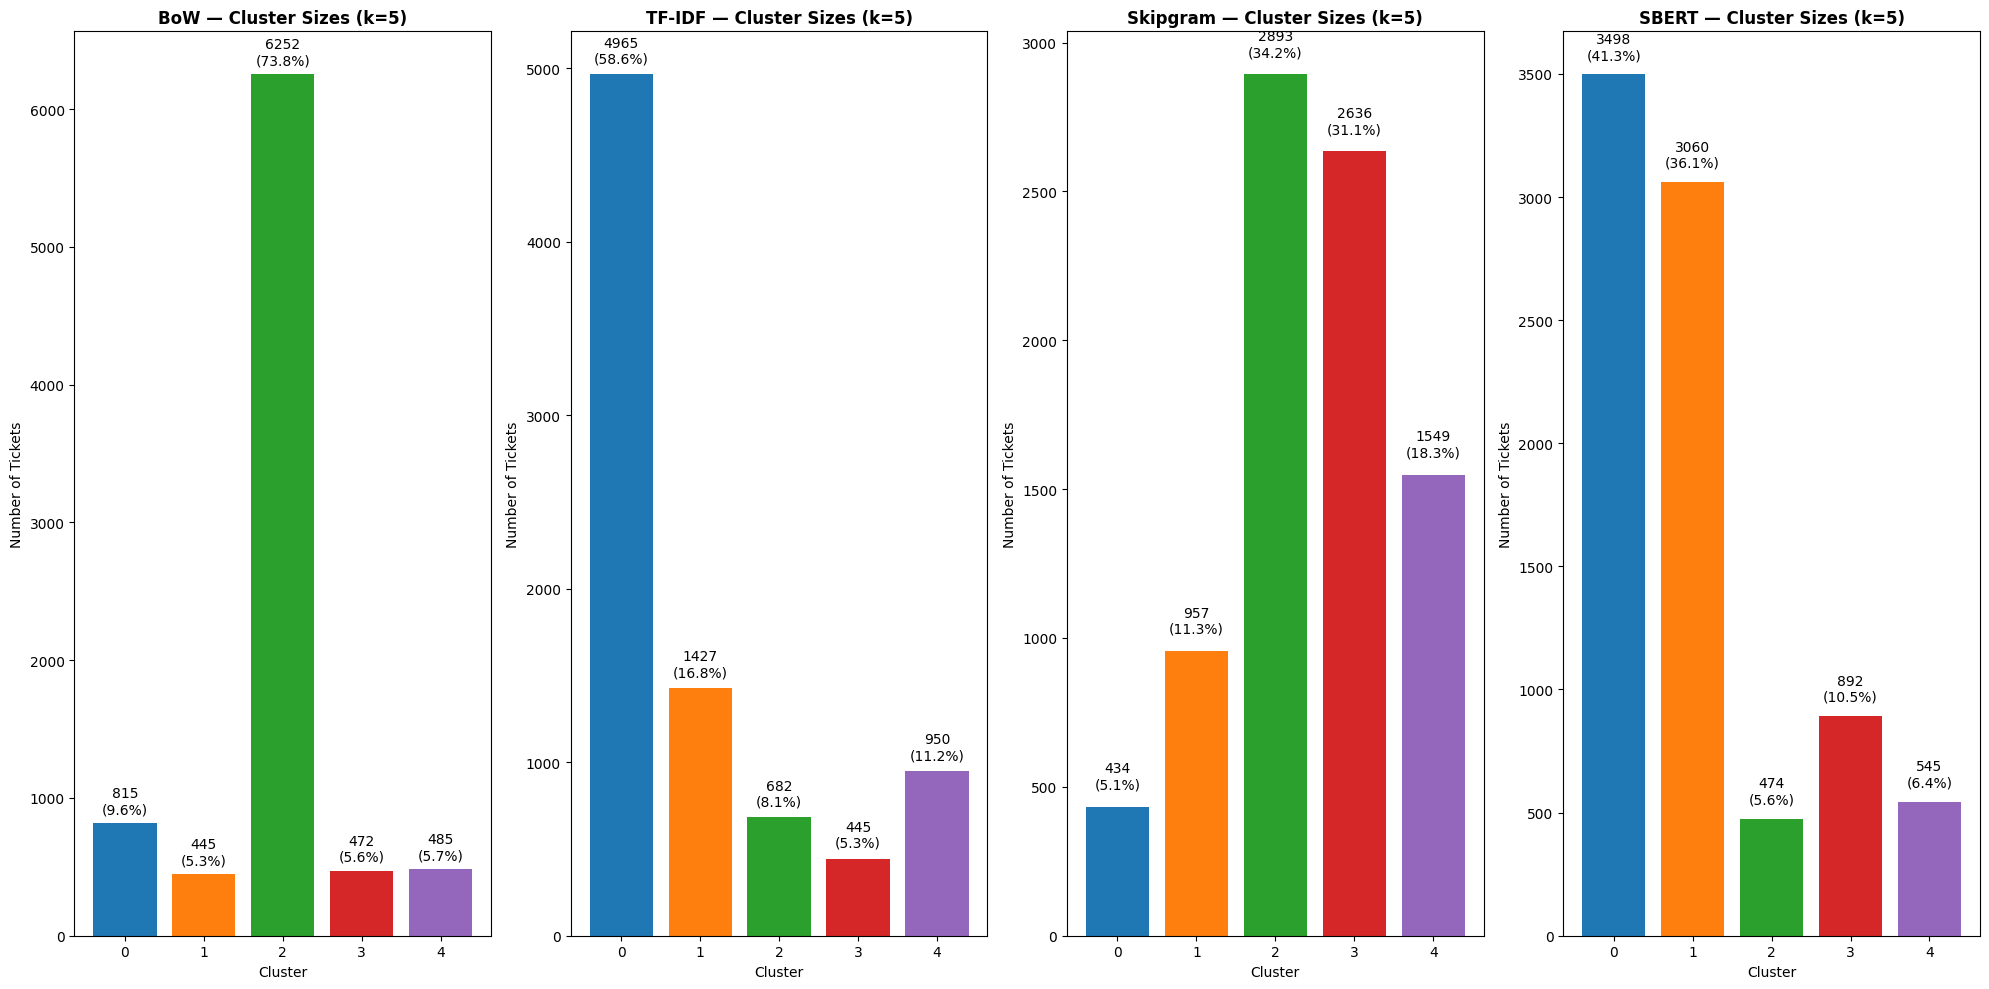

In [18]:
plot_cluster_size([(km_bow_labels, "BoW"),(km_tfidf_labels, "TF-IDF"),(km_skipgram_labels, "Skipgram"), (km_sbert_labels, "SBERT")])

## CLUSTER STABILITY

#### CLUSTER STABILITY ACCROSS K-VALUES ON KMEAN

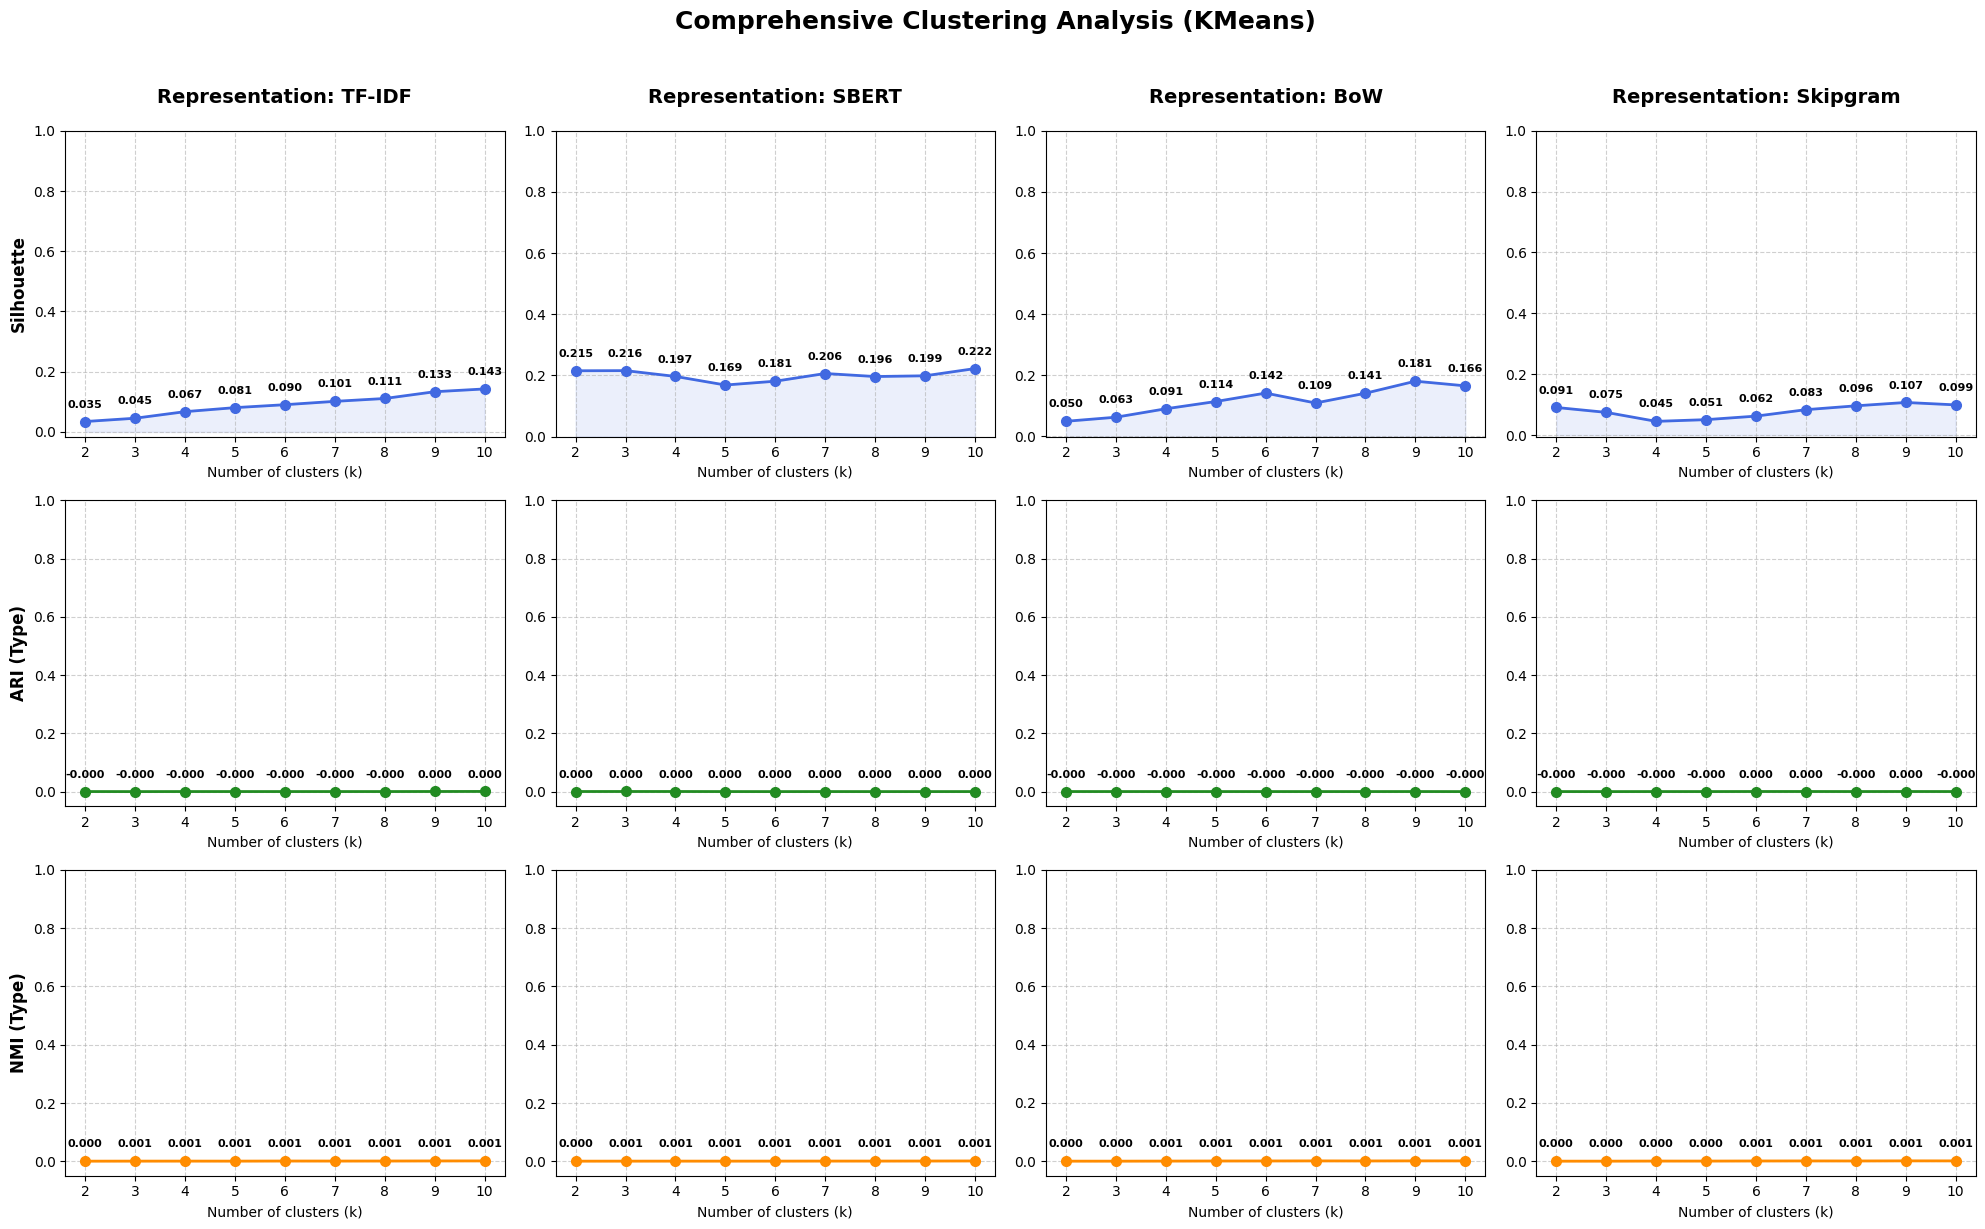

In [19]:
visualize_cluster_stability(df = all_results, algorithm='KMeans')